In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from IPython.display import display
from astropy.coordinates import SkyCoord
import astropy.units as u

In [33]:
# Define column names based on the header in the SRL file
column_names = [
    "Source_id", "Isl_id", "RA", "E_RA", "DEC", "E_DEC", "Total_flux", "E_Total_flux",
    "Peak_flux", "E_Peak_flux", "RA_max", "E_RA_max", "DEC_max", "E_DEC_max", "Maj", 
    "E_Maj", "Min", "E_Min", "PA", "E_PA", "Maj_img_plane", "E_Maj_img_plane", 
    "Min_img_plane", "E_Min_img_plane", "PA_img_plane", "E_PA_img_plane", "DC_Maj", 
    "E_DC_Maj", "DC_Min", "E_DC_Min", "DC_PA", "E_DC_PA", "DC_Maj_img_plane", 
    "E_DC_Maj_img_plane", "DC_Min_img_plane", "E_DC_Min_img_plane", "DC_PA_img_plane", 
    "E_DC_PA_img_plane", "Isl_Total_flux", "E_Isl_Total_flux", "Isl_rms", "Isl_mean", 
    "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"
]

In [34]:
spw = [
       2,
       3 , 
       4, 
       5, 
       6, 
       8, 
       15, 
       16, 
       17
       ]

In [35]:
srl_file_paths = []
dataframes = []

for s in spw:
    paths = [
        f'../paper1/23/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/25/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/32/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/36/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl'
    ]
    srl_file_paths.append(paths)
    
    spw_data = []
    for path in paths:
        try:
            df = pd.read_csv(path, delim_whitespace=True, comment='#', names=column_names)
            spw_data.append(df)
        except FileNotFoundError:
            print(f"File not found: {path}")
    
    if spw_data:
        combined_df = pd.concat(spw_data, ignore_index=True)
        dataframes.append(combined_df)

# Optionally, check the content of dataframes
print(f"Total dataframes read: {len(dataframes)}")

File not found: ../paper1/32/spw2-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw3-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw4-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw5-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw6-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw8-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw15-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw16-2.5arcsec-nit5000--awproject.pybdsf.srl
File not found: ../paper1/32/spw17-2.5arcsec-nit5000--awproject.pybdsf.srl
Total dataframes read: 9


In [42]:
# Identify repeated sources in each SPW dataframe
repeated_sources = []

for i, df in enumerate(dataframes):
    # Group by RA and DEC to find duplicates
    duplicated = df[df.duplicated(subset=['RA', 'DEC'], keep=False)]
    repeated_sources.append(duplicated)
    print(f"Repeated sources in SPW {spw[i]}:")
    print(duplicated)

# Optionally, store the repeated sources for further analysis
for i, df in enumerate(repeated_sources):
    df.to_csv(f'repeated_sources_spw{spw[i]}.csv', index=False)

Repeated sources in SPW 2:
Empty DataFrame
Columns: [Source_id, Isl_id, RA, E_RA, DEC, E_DEC, Total_flux, E_Total_flux, Peak_flux, E_Peak_flux, RA_max, E_RA_max, DEC_max, E_DEC_max, Maj, E_Maj, Min, E_Min, PA, E_PA, Maj_img_plane, E_Maj_img_plane, Min_img_plane, E_Min_img_plane, PA_img_plane, E_PA_img_plane, DC_Maj, E_DC_Maj, DC_Min, E_DC_Min, DC_PA, E_DC_PA, DC_Maj_img_plane, E_DC_Maj_img_plane, DC_Min_img_plane, E_DC_Min_img_plane, DC_PA_img_plane, E_DC_PA_img_plane, Isl_Total_flux, E_Isl_Total_flux, Isl_rms, Isl_mean, Resid_Isl_rms, Resid_Isl_mean, S_Code]
Index: []

[0 rows x 45 columns]
Repeated sources in SPW 3:
Empty DataFrame
Columns: [Source_id, Isl_id, RA, E_RA, DEC, E_DEC, Total_flux, E_Total_flux, Peak_flux, E_Peak_flux, RA_max, E_RA_max, DEC_max, E_DEC_max, Maj, E_Maj, Min, E_Min, PA, E_PA, Maj_img_plane, E_Maj_img_plane, Min_img_plane, E_Min_img_plane, PA_img_plane, E_PA_img_plane, DC_Maj, E_DC_Maj, DC_Min, E_DC_Min, DC_PA, E_DC_PA, DC_Maj_img_plane, E_DC_Maj_img_plane, D

/var/folders/l1/vk05brrd5vgg5rxsglsqwbjh0000gn/T/ipykernel_92933/2154577651.py:10: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(coords.ra.deg, coords.dec.deg, label=f'SPW {spw[i]}', alpha=0.7, edgecolors='w', s=50, marker=marker, color=color)


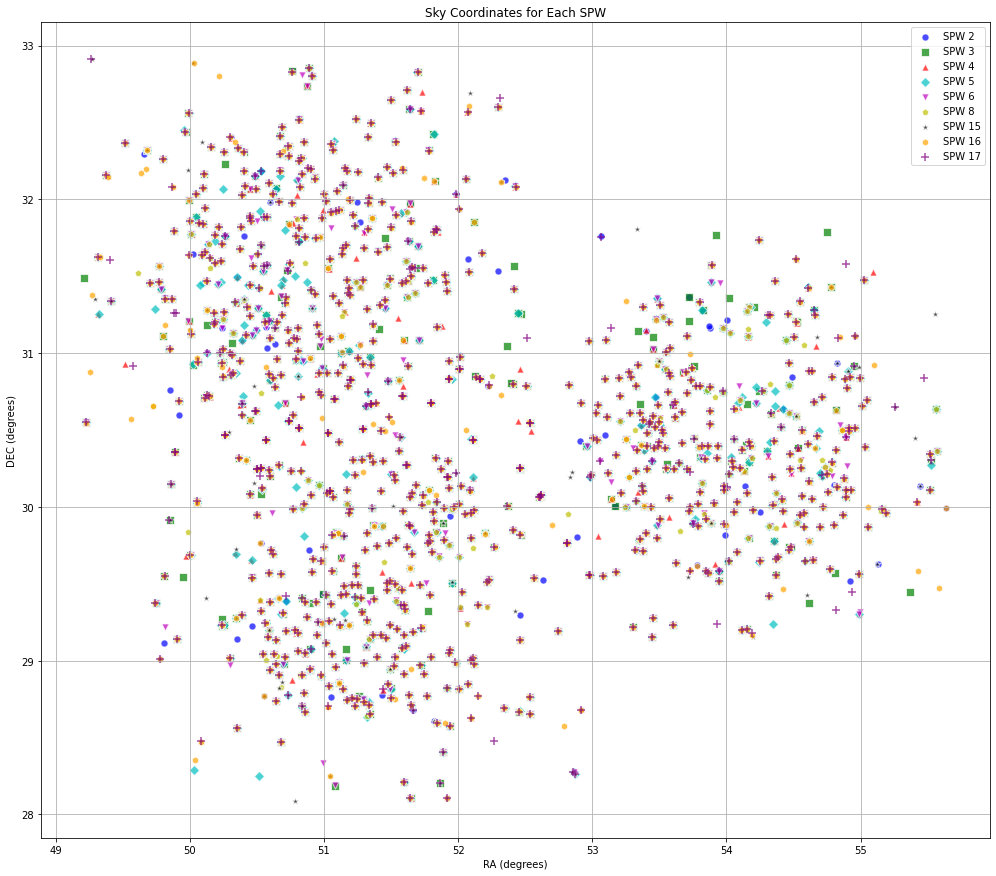

In [41]:
# Define markers and colors for different SPWs
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '+']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple']

# Plotting RA and DEC using SkyCoord
plt.figure(figsize=(17, 15))
for i, (df, marker, color) in enumerate(zip(dataframes, markers, colors)):
    # Convert RA and DEC to SkyCoord
    coords = SkyCoord(ra=df['RA'].values * u.degree, dec=df['DEC'].values * u.degree, frame='icrs')
    plt.scatter(coords.ra.deg, coords.dec.deg, label=f'SPW {spw[i]}', alpha=0.7, edgecolors='w', s=50, marker=marker, color=color)

plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')
plt.title('Sky Coordinates for Each SPW')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
# Function to round RA and DEC
def round_ra_dec(dataframe, decimal=2):
    dataframe['RA_rounded'] = dataframe['RA'].round(decimal)
    dataframe['DEC_rounded'] = dataframe['DEC'].round(decimal)
    return dataframe

In [30]:
# Apply rounding function
dataframes = [round_ra_dec(df) for df in dataframes]

In [31]:
# Add identifier for each dataframe
df_names = ["2", "3", "4", "5", "6", "8", "15", "16", "17"]
for i, df in enumerate(dataframes):
    df['source_df'] = df_names[i]

In [32]:
# Combine all dataframes
df_combined = pd.concat(dataframes, ignore_index=True)

In [33]:
df_combined

,Source_id,Isl_id,RA,E_RA,DEC,E_DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,...,Isl_Total_flux,E_Isl_Total_flux,Isl_rms,Isl_mean,Resid_Isl_rms,Resid_Isl_mean,S_Code,RA_rounded,DEC_rounded,source_df
0,0,0,52.563716,0.000423,29.535504,0.000356,0.002557,0.000368,0.002682,0.000219,...,0.002193,0.000182,0.000222,-0.000022,0.000030,-0.000021,S,52.56,29.54,2
1,1,1,52.461059,0.000463,29.133039,0.000386,0.003505,0.000458,0.002950,0.000235,...,0.002939,0.000204,0.000227,-0.000022,0.000067,-0.000020,S,52.46,29.13,2
2,2,2,52.464918,0.000276,29.821470,0.000174,0.005155,0.000374,0.004693,0.000201,...,0.004722,0.000230,0.000199,-0.000022,0.000092,-0.000017,S,52.46,29.82,2
3,3,3,52.409015,0.000564,29.847167,0.000717,0.001433,0.000310,0.001354,0.000172,...,0.001055,0.000131,0.000170,-0.000022,0.000040,-0.000021,S,52.41,29.85,2
4,4,4,52.272299,0.000512,29.737712,0.000486,0.002703,0.000449,0.002522,0.000247,...,0.002196,0.000191,0.000244,-0.000022,0.000069,-0.000021,S,52.27,29.74,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2222,247,239,50.342828,0.001288,29.729799,0.000907,0.000803,0.000267,0.000764,0.000148,...,0.000431,0.000086,0.000148,-0.000023,0.000005,-0.000023,S,50.34,29.73,17
2223,248,240,50.320429,0.002110,28.983415,0.001109,0.002175,0.000671,0.001513,0.000288,...,0.001198,0.000221,0.000293,-0.000023,0.000030,-0.000023,S,50.32,28.98,17
2224,249,241,50.298427,0.001127,29.014384,0.000905,0.003278,0.000774,0.002393,0.000356,...,0.002321,0.000298,0.000342,-0.000023,0.000042,-0.000023,S,50.30,29.01,17
2225,250,242,50.257155,0.001418,29.201577,0.000711,0.000974,0.000277,0.000821,0.000140,...,0.000569,0.000093,0.000138,-0.000023,0.000009,-0.000023,S,50.26,29.20,17


In [34]:
# Step 3: Group by rounded RA and DEC and filter duplicates
grouped = df_combined.groupby(['RA_rounded', 'DEC_rounded'])
duplicates = grouped.filter(lambda x: len(x) > 1)

In [35]:
duplicates

,Source_id,Isl_id,RA,E_RA,DEC,E_DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,...,Isl_Total_flux,E_Isl_Total_flux,Isl_rms,Isl_mean,Resid_Isl_rms,Resid_Isl_mean,S_Code,RA_rounded,DEC_rounded,source_df
0,0,0,52.563716,0.000423,29.535504,0.000356,0.002557,0.000368,0.002682,0.000219,...,0.002193,0.000182,0.000222,-0.000022,0.000030,-0.000021,S,52.56,29.54,2
1,1,1,52.461059,0.000463,29.133039,0.000386,0.003505,0.000458,0.002950,0.000235,...,0.002939,0.000204,0.000227,-0.000022,0.000067,-0.000020,S,52.46,29.13,2
2,2,2,52.464918,0.000276,29.821470,0.000174,0.005155,0.000374,0.004693,0.000201,...,0.004722,0.000230,0.000199,-0.000022,0.000092,-0.000017,S,52.46,29.82,2
3,3,3,52.409015,0.000564,29.847167,0.000717,0.001433,0.000310,0.001354,0.000172,...,0.001055,0.000131,0.000170,-0.000022,0.000040,-0.000021,S,52.41,29.85,2
4,4,4,52.272299,0.000512,29.737712,0.000486,0.002703,0.000449,0.002522,0.000247,...,0.002196,0.000191,0.000244,-0.000022,0.000069,-0.000021,S,52.27,29.74,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2218,243,236,50.446175,0.000528,30.081100,0.000423,0.001946,0.000265,0.001789,0.000143,...,0.002236,0.000222,0.000142,-0.000023,0.000014,-0.000023,C,50.45,30.08,17
2220,245,237,50.386802,0.000502,29.297072,0.000347,0.002438,0.000363,0.002769,0.000226,...,0.001994,0.000172,0.000236,-0.000023,0.000035,-0.000023,S,50.39,29.30,17
2222,247,239,50.342828,0.001288,29.729799,0.000907,0.000803,0.000267,0.000764,0.000148,...,0.000431,0.000086,0.000148,-0.000023,0.000005,-0.000023,S,50.34,29.73,17
2224,249,241,50.298427,0.001127,29.014384,0.000905,0.003278,0.000774,0.002393,0.000356,...,0.002321,0.000298,0.000342,-0.000023,0.000042,-0.000023,S,50.30,29.01,17


In [36]:
# Step 4: Create a new DataFrame with custom columns
result_df = pd.DataFrame()

In [37]:
# Columns of interest without errors
base_columns = ['Total_flux', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'Isl_rms']

In [38]:
# Iterate over each group of duplicates
for name, group in duplicates.groupby(['RA_rounded', 'DEC_rounded']):
    temp_df = pd.DataFrame({'RA': [group['RA'].iloc[0]], 'DEC': [group['DEC'].iloc[0]]})
    for df_name in df_names:
        specific_group = group[group['source_df'] == df_name]
        if not specific_group.empty:
            for column in base_columns:
                new_column_name = f"{column}_{df_name}"
                temp_df[new_column_name] = specific_group[column].values[0] if not specific_group[column].empty else None
    result_df = pd.concat([result_df, temp_df], ignore_index=True)

In [39]:
# Scale flux values
for df_name in df_names:
    for column in base_columns:
        col_name = f"{column}_{df_name}"
        if col_name in result_df.columns:
            result_df[col_name] *= 1e3

In [40]:
# Rename columns
rename_dict = {
    r'$RA\, (\mathrm{\tiny degrees})$': 'RA',
    r'$\sigma_{\mathrm{RA}}\, (\mathrm{\tiny degrees})$': 'E_RA',
    r'$DEC\, (\mathrm{\tiny degrees})$': 'DEC',
    r'$\sigma_{\mathrm{DEC}}\, (\mathrm{\tiny degrees})$': 'E_DEC',
    r'$S_{\mathrm{total}}\, (\mathrm{\tiny mJy})$': 'Total_flux',
    r'$\sigma_{S_{\mathrm{total}}}\, (\mathrm{\tiny mJy})$': 'E_Total_flux',
    r'$S_{\mathrm{peak}}\, (\mathrm{\tiny mJy\,beam^{-1}})$': 'Peak_flux',
    r'$\sigma_{S_{\mathrm{peak}}}\, (\mathrm{\tiny mJy\,beam^{-1}})$': 'E_Peak_flux'
}

In [41]:
result_df = result_df.rename(columns=rename_dict)

In [42]:
result_df

,RA,DEC,Total_flux_2,E_Total_flux_2,Peak_flux_2,E_Peak_flux_2,Isl_rms_2,Total_flux_3,E_Total_flux_3,Peak_flux_3,...,Total_flux_6,E_Total_flux_6,Peak_flux_6,E_Peak_flux_6,Isl_rms_6,Total_flux_8,E_Total_flux_8,Peak_flux_8,E_Peak_flux_8,Isl_rms_8
0,50.238461,29.229413,2.777872,0.483668,2.280973,0.242565,0.235073,3.711502,0.658761,1.633992,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50.295338,29.014911,NaN,NaN,NaN,NaN,NaN,2.069131,0.517928,1.512041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50.297136,29.016462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,50.342044,29.274835,NaN,NaN,NaN,NaN,NaN,1.397025,0.449014,1.161748,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,50.343151,29.728088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,52.409015,29.847167,1.433437,0.309865,1.354219,0.171788,0.169979,1.466642,0.223692,1.580201,...,1.084233,0.267898,1.073049,0.150776,0.153626,0.740126,0.249413,0.733069,0.138367,0.143453
330,52.461059,29.133039,3.504796,0.457789,2.949699,0.234907,0.226663,2.581091,0.501657,1.857139,...,1.770855,0.304953,1.543612,0.160314,0.155682,NaN,NaN,NaN,NaN,NaN
331,52.464918,29.821470,5.154544,0.374027,4.693250,0.201068,0.198853,NaN,NaN,NaN,...,2.422631,0.295709,2.410768,0.169000,0.170119,NaN,NaN,NaN,NaN,NaN
332,52.465279,29.820843,NaN,NaN,NaN,NaN,NaN,4.090558,0.332317,3.758153,...,NaN,NaN,NaN,NaN,NaN,1.501734,0.450797,1.286068,0.233522,0.226827


In [43]:
# Export the result to a LaTeX table
latex_table = result_df.to_latex(index=False, longtable=True, header=True)
with open('table.tex', 'w') as file:
    file.write(latex_table)

/var/folders/l1/vk05brrd5vgg5rxsglsqwbjh0000gn/T/ipykernel_17743/2156565626.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = result_df.to_latex(index=False, longtable=True, header=True)


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from IPython.display import display

# Define column names based on the header in the SRL file
column_names = [
    "Source_id", "Isl_id", "RA", "E_RA", "DEC", "E_DEC", "Total_flux", "E_Total_flux",
    "Peak_flux", "E_Peak_flux", "RA_max", "E_RA_max", "DEC_max", "E_DEC_max", "Maj", 
    "E_Maj", "Min", "E_Min", "PA", "E_PA", "Maj_img_plane", "E_Maj_img_plane", 
    "Min_img_plane", "E_Min_img_plane", "PA_img_plane", "E_PA_img_plane", "DC_Maj", 
    "E_DC_Maj", "DC_Min", "E_DC_Min", "DC_PA", "E_DC_PA", "DC_Maj_img_plane", 
    "E_DC_Maj_img_plane", "DC_Min_img_plane", "E_DC_Min_img_plane", "DC_PA_img_plane", 
    "E_DC_PA_img_plane", "Isl_Total_flux", "E_Isl_Total_flux", "Isl_rms", "Isl_mean", 
    "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"
]

# File paths
srl_file_paths = [
    '../server/source_detection/spw/4-spw2-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw3-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw4-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw5-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw6-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw8-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw15-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw16-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw17-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
]

# Read files into dataframes
dataframes = [pd.read_csv(path, delim_whitespace=True, comment='#', names=column_names) for path in srl_file_paths]

# Function to round RA and DEC
def round_ra_dec(dataframe, decimal=2):
    dataframe['RA_rounded'] = dataframe['RA'].round(decimal)
    dataframe['DEC_rounded'] = dataframe['DEC'].round(decimal)
    return dataframe

# Apply rounding function
dataframes = [round_ra_dec(df) for df in dataframes]

# Add identifier for each dataframe
df_names = ["2", "3", "4", "5", "6", "8", "15", "16", "17"]
for i, df in enumerate(dataframes):
    df['source_df'] = df_names[i]

# Combine all dataframes
df_combined = pd.concat(dataframes, ignore_index=True)

# Step 3: Group by rounded RA and DEC and filter duplicates
grouped = df_combined.groupby(['RA_rounded', 'DEC_rounded'])
duplicates = grouped.filter(lambda x: len(x) > 1)

# Step 4: Create a new DataFrame with custom columns
result_df = pd.DataFrame()

# Columns of interest without errors
base_columns = ['Total_flux', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'Isl_rms']

# Iterate over each group of duplicates
for name, group in duplicates.groupby(['RA_rounded', 'DEC_rounded']):
    temp_df = pd.DataFrame({'RA': [group['RA'].iloc[0]], 'DEC': [group['DEC'].iloc[0]]})
    for df_name in df_names:
        specific_group = group[group['source_df'] == df_name]
        if not specific_group.empty:
            for column in base_columns:
                new_column_name = f"{column}_{df_name}"
                temp_df[new_column_name] = specific_group[column].values[0] if not specific_group[column].empty else None
    result_df = pd.concat([result_df, temp_df], ignore_index=True)

# Scale flux values
for df_name in df_names:
    for column in base_columns:
        col_name = f"{column}_{df_name}"
        if col_name in result_df.columns:
            result_df[col_name] *= 1e3

# Rename columns
rename_dict = {
    'RA': r'$RA\, (\mathrm{degrees})$',
    'DEC': r'$DEC\, (\mathrm{degrees})$'
}
for df_name in df_names:
    rename_dict.update({
        f'Total_flux_{df_name}': f'$S_{{\\mathrm{{total,{df_name}}}}}\, (\\mathrm{{mJy}})$',
        f'E_Total_flux_{df_name}': f'$\\sigma_{{S_{{\\mathrm{{total,{df_name}}}}}}}\, (\\mathrm{{mJy}})$',
        f'Peak_flux_{df_name}': f'$S_{{\\mathrm{{peak,{df_name}}}}}\, (\\mathrm{{mJy\\,beam^{-1}}})$',
        f'E_Peak_flux_{df_name}': f'$\\sigma_{{S_{{\\mathrm{{peak,{df_name}}}}}}}\, (\\mathrm{{mJy\\,beam^{-1}}})$',
        f'Isl_rms_{df_name}': f'$\\mathrm{{Isl\\_rms\\_{df_name}}}$'
    })

result_df = result_df.rename(columns=rename_dict)

# Export the result to a LaTeX table
latex_table = result_df.to_latex(index=False, longtable=True, header=True, escape=False)
with open('table.tex', 'w') as file:
    file.write(latex_table)

# Print a preview of the LaTeX table
print(latex_table)


/var/folders/l1/vk05brrd5vgg5rxsglsqwbjh0000gn/T/ipykernel_17743/3130500743.py:98: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = result_df.to_latex(index=False, longtable=True, header=True, escape=False)


\begin{longtable}{rrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 $RA\, (\mathrm{degrees})$ &  $DEC\, (\mathrm{degrees})$ &  $S_{\mathrm{total,2}}\, (\mathrm{mJy})$ &  $\sigma_{S_{\mathrm{total,2}}}\, (\mathrm{mJy})$ &  $S_{\mathrm{peak,2}}\, (\mathrm{mJy\,beam^-1})$ &  $\sigma_{S_{\mathrm{peak,2}}}\, (\mathrm{mJy\,beam^-1})$ &  $\mathrm{Isl\_rms\_2}$ &  $S_{\mathrm{total,3}}\, (\mathrm{mJy})$ &  $\sigma_{S_{\mathrm{total,3}}}\, (\mathrm{mJy})$ &  $S_{\mathrm{peak,3}}\, (\mathrm{mJy\,beam^-1})$ &  $\sigma_{S_{\mathrm{peak,3}}}\, (\mathrm{mJy\,beam^-1})$ &  $\mathrm{Isl\_rms\_3}$ &  $S_{\mathrm{total,4}}\, (\mathrm{mJy})$ &  $\sigma_{S_{\mathrm{total,4}}}\, (\mathrm{mJy})$ &  $S_{\mathrm{peak,4}}\, (\mathrm{mJy\,beam^-1})$ &  $\sigma_{S_{\mathrm{peak,4}}}\, (\mathrm{mJy\,beam^-1})$ &  $\mathrm{Isl\_rms\_4}$ &  $S_{\mathrm{total,5}}\, (\mathrm{mJy})$ &  $\sigma_{S_{\mathrm{total,5}}}\, (\mathrm{mJy})$ &  $S_{\mathrm{peak,5}}\, (\mathrm{mJy\,beam^-1})$ &  $\sigma_{S_{\mathrm{pe

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from IPython.display import display

# Define column names based on the header in the SRL file
column_names = [
    "Source_id", "Isl_id", "RA", "E_RA", "DEC", "E_DEC", "Total_flux", "E_Total_flux",
    "Peak_flux", "E_Peak_flux", "RA_max", "E_RA_max", "DEC_max", "E_DEC_max", "Maj", 
    "E_Maj", "Min", "E_Min", "PA", "E_PA", "Maj_img_plane", "E_Maj_img_plane", 
    "Min_img_plane", "E_Min_img_plane", "PA_img_plane", "E_PA_img_plane", "DC_Maj", 
    "E_DC_Maj", "DC_Min", "E_DC_Min", "DC_PA", "E_DC_PA", "DC_Maj_img_plane", 
    "E_DC_Maj_img_plane", "DC_Min_img_plane", "E_DC_Min_img_plane", "DC_PA_img_plane", 
    "E_DC_PA_img_plane", "Isl_Total_flux", "E_Isl_Total_flux", "Isl_rms", "Isl_mean", 
    "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"
]

# File paths
srl_file_paths = [
    '../server/source_detection/spw/4-spw2-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw3-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw4-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw5-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw6-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw8-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw15-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw16-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw17-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
]

# Read files into dataframes
dataframes = [pd.read_csv(path, delim_whitespace=True, comment='#', names=column_names) for path in srl_file_paths]

# Function to round RA and DEC
def round_ra_dec(dataframe, decimal=2):
    dataframe['RA_rounded'] = dataframe['RA'].round(decimal)
    dataframe['DEC_rounded'] = dataframe['DEC'].round(decimal)
    return dataframe

# Apply rounding function
dataframes = [round_ra_dec(df) for df in dataframes]

# Add identifier for each dataframe
df_names = ["2", "3", "4", "5", "6", "8", "15", "16", "17"]
for i, df in enumerate(dataframes):
    df['source_df'] = df_names[i]

# Combine all dataframes
df_combined = pd.concat(dataframes, ignore_index=True)

# Step 3: Group by rounded RA and DEC and filter duplicates
grouped = df_combined.groupby(['RA_rounded', 'DEC_rounded'])
duplicates = grouped.filter(lambda x: len(x) > 1)

# Step 4: Create a new DataFrame with custom columns
result_df = pd.DataFrame()

# Columns of interest without errors
base_columns = ['Total_flux', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'Isl_rms']

# Iterate over each group of duplicates
for name, group in duplicates.groupby(['RA_rounded', 'DEC_rounded']):
    temp_df = pd.DataFrame({'RA': [group['RA'].iloc[0]], 'DEC': [group['DEC'].iloc[0]]})
    for df_name in df_names:
        specific_group = group[group['source_df'] == df_name]
        if not specific_group.empty:
            for column in base_columns:
                new_column_name = f"{column}_{df_name}"
                temp_df[new_column_name] = specific_group[column].values[0] if not specific_group[column].empty else None
    result_df = pd.concat([result_df, temp_df], ignore_index=True)

# Scale flux values
for df_name in df_names:
    for column in base_columns:
        col_name = f"{column}_{df_name}"
        if col_name in result_df.columns:
            result_df[col_name] *= 1e3

# Rename columns
rename_dict = {
    'RA': r'$RA\, (\mathrm{degrees})$',
    'DEC': r'$DEC\, (\mathrm{degrees})$'
}
for df_name in df_names:
    rename_dict.update({
        f'Total_flux_{df_name}': f'$S_{{\\mathrm{{total,{df_name}}}}}\, (\\mathrm{{mJy}})$',
        f'E_Total_flux_{df_name}': f'$\\sigma_{{S_{{\\mathrm{{total,{df_name}}}}}}}\, (\\mathrm{{mJy}})$',
        f'Peak_flux_{df_name}': f'$S_{{\\mathrm{{peak,{df_name}}}}}\, (\\mathrm{{mJy\\,beam^{-1}}})$',
        f'E_Peak_flux_{df_name}': f'$\\sigma_{{S_{{\\mathrm{{peak,{df_name}}}}}}}\, (\\mathrm{{mJy\\,beam^{-1}}})$',
        f'Isl_rms_{df_name}': f'$\\mathrm{{Isl\\_rms\\_{df_name}}}$'
    })

result_df = result_df.rename(columns=rename_dict)

# Export the result to a LaTeX table
latex_table = result_df.to_latex(index=False, longtable=True, header=True, escape=False)
with open('table.tex', 'w') as file:
    file.write(latex_table)

# Print a preview of the LaTeX table
print(latex_table)


\begin{longtable}{rrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 $RA\, (\mathrm{degrees})$ &  $DEC\, (\mathrm{degrees})$ &  $S_{\mathrm{total,2}}\, (\mathrm{mJy})$ &  $\sigma_{S_{\mathrm{total,2}}}\, (\mathrm{mJy})$ &  $S_{\mathrm{peak,2}}\, (\mathrm{mJy\,beam^-1})$ &  $\sigma_{S_{\mathrm{peak,2}}}\, (\mathrm{mJy\,beam^-1})$ &  $\mathrm{Isl\_rms\_2}$ &  $S_{\mathrm{total,3}}\, (\mathrm{mJy})$ &  $\sigma_{S_{\mathrm{total,3}}}\, (\mathrm{mJy})$ &  $S_{\mathrm{peak,3}}\, (\mathrm{mJy\,beam^-1})$ &  $\sigma_{S_{\mathrm{peak,3}}}\, (\mathrm{mJy\,beam^-1})$ &  $\mathrm{Isl\_rms\_3}$ &  $S_{\mathrm{total,4}}\, (\mathrm{mJy})$ &  $\sigma_{S_{\mathrm{total,4}}}\, (\mathrm{mJy})$ &  $S_{\mathrm{peak,4}}\, (\mathrm{mJy\,beam^-1})$ &  $\sigma_{S_{\mathrm{peak,4}}}\, (\mathrm{mJy\,beam^-1})$ &  $\mathrm{Isl\_rms\_4}$ &  $S_{\mathrm{total,5}}\, (\mathrm{mJy})$ &  $\sigma_{S_{\mathrm{total,5}}}\, (\mathrm{mJy})$ &  $S_{\mathrm{peak,5}}\, (\mathrm{mJy\,beam^-1})$ &  $\sigma_{S_{\mathrm{pe

/var/folders/l1/vk05brrd5vgg5rxsglsqwbjh0000gn/T/ipykernel_17743/3130500743.py:98: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = result_df.to_latex(index=False, longtable=True, header=True, escape=False)


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from IPython.display import display

# Define column names based on the header in the SRL file
column_names = [
    "Source_id", "Isl_id", "RA", "E_RA", "DEC", "E_DEC", "Total_flux", "E_Total_flux",
    "Peak_flux", "E_Peak_flux", "RA_max", "E_RA_max", "DEC_max", "E_DEC_max", "Maj", 
    "E_Maj", "Min", "E_Min", "PA", "E_PA", "Maj_img_plane", "E_Maj_img_plane", 
    "Min_img_plane", "E_Min_img_plane", "PA_img_plane", "E_PA_img_plane", "DC_Maj", 
    "E_DC_Maj", "DC_Min", "E_DC_Min", "DC_PA", "E_DC_PA", "DC_Maj_img_plane", 
    "E_DC_Maj_img_plane", "DC_Min_img_plane", "E_DC_Min_img_plane", "DC_PA_img_plane", 
    "E_DC_PA_img_plane", "Isl_Total_flux", "E_Isl_Total_flux", "Isl_rms", "Isl_mean", 
    "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"
]

# File paths
srl_file_paths = [
    '../server/source_detection/spw/4-spw2-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw3-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw4-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw5-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw6-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw8-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw15-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw16-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl',
    '../server/source_detection/spw/4-spw17-2.5arcsec-nit5000-1e-4-mosaic.image.pybdsf.srl'
]

# Read files into dataframes
dataframes = [pd.read_csv(path, delim_whitespace=True, comment='#', names=column_names) for path in srl_file_paths]

# Function to round RA and DEC
def round_ra_dec(dataframe, decimal=2):
    dataframe['RA_rounded'] = dataframe['RA'].round(decimal)
    dataframe['DEC_rounded'] = dataframe['DEC'].round(decimal)
    return dataframe

# Apply rounding function
dataframes = [round_ra_dec(df) for df in dataframes]

# Add identifier for each dataframe
df_names = ["2", "3", "4", "5", "6", "8", "15", "16", "17"]
for i, df in enumerate(dataframes):
    df['source_df'] = df_names[i]

# Combine all dataframes
df_combined = pd.concat(dataframes, ignore_index=True)

# Step 3: Group by rounded RA and DEC and filter duplicates
grouped = df_combined.groupby(['RA_rounded', 'DEC_rounded'])
duplicates = grouped.filter(lambda x: len(x) > 1)

# Step 4: Create a new DataFrame with custom columns
result_df = pd.DataFrame()

# Columns of interest without errors
base_columns = ['Total_flux', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'Isl_rms']

# Iterate over each group of duplicates
for name, group in duplicates.groupby(['RA_rounded', 'DEC_rounded']):
    temp_df = pd.DataFrame({'RA': [group['RA'].iloc[0]], 'DEC': [group['DEC'].iloc[0]]})
    for df_name in df_names:
        specific_group = group[group['source_df'] == df_name]
        if not specific_group.empty:
            for column in base_columns:
                new_column_name = f"{column}_{df_name}"
                temp_df[new_column_name] = specific_group[column].values[0] if not specific_group[column].empty else None
    result_df = pd.concat([result_df, temp_df], ignore_index=True)

# Scale flux values
for df_name in df_names:
    for column in base_columns:
        col_name = f"{column}_{df_name}"
        if col_name in result_df.columns:
            result_df[col_name] *= 1e3

# Rename columns
rename_dict = {
    'RA': r'$RA\, (\mathrm{degrees})$',
    'DEC': r'$DEC\, (\mathrm{degrees})$'
}
for df_name in df_names:
    rename_dict.update({
        f'Total_flux_{df_name}': f'$S_{{\\mathrm{{total,{df_name}}}}}\, (\\mathrm{{mJy}})$',
        f'E_Total_flux_{df_name}': f'$\\sigma_{{S_{{\\mathrm{{total,{df_name}}}}}}}\, (\\mathrm{{mJy}})$',
        f'Peak_flux_{df_name}': f'$S_{{\\mathrm{{peak,{df_name}}}}}\, (\\mathrm{{mJy\,beam^{-1}}}})$',
        f'E_Peak_flux_{df_name}': f'$\\sigma_{{S_{{\\mathrm{{peak,{df_name}}}}}}}\, (\\mathrm{{mJy\,beam^{-1}}}})$',
        f'Isl_rms_{df_name}': f'$\\mathrm{{Isl\\_rms\\_{df_name}}}$'
    })

result_df = result_df.rename(columns=rename_dict)

# Export the result to a LaTeX table
latex_table = result_df.to_latex(index=False, longtable=True, header=True, escape=False)
with open('table.tex', 'w') as file:
    file.write(latex_table)

# Print a preview of the LaTeX table
print(latex_table)



SyntaxError: f-string: single '}' is not allowed (1812582667.py, line 90)